<a href="https://colab.research.google.com/github/Eng3mr5aled/Machine-Learning-_python/blob/main/MLR_DR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ✈️ ML Session — Classification, Metrics & Decision Trees
### For first-time learners

**What we cover today:**
1. Multi-class Classification
2. Cross-Entropy Loss + Confusion Matrix + Metrics
3. Decision Trees
4. Real-world Application — We decide together what to do!

---

In [ ]:
# ── All imports in one place ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    log_loss, classification_report
)
from sklearn.preprocessing import LabelEncoder

print('Ready ✅')

Ready ✅


---
## Part 1 — Multi-class Classification

**Binary classification** → only 2 options: Yes or No, Pass or Fail, Spam or Not Spam.

**Multi-class classification** → more than 2 options. Example: predicting a student's grade: **A, B, C, or Fail**.

The model looks at features (study hours, attendance…) and assigns the input to one of those classes.

In [ ]:
# Load dataset — each row is a student, each column is a feature
df = pd.read_csv('students.csv')
print(f'Dataset: {df.shape[0]} students, {df.shape[1]} columns')
df.head(8)

Dataset: 200 students, 7 columns


,study_hours,sleep_hours,attendance_pct,prev_score,final_score,grade,passed
0,1.7,7.8,84,41,63.2,C,1
1,8.0,4.3,96,74,90.1,A,1
2,4.9,7.7,55,57,66.3,C,1
3,7.5,8.7,93,45,85.8,A,1
4,9.8,7.0,76,87,99.4,A,1
5,5.8,5.4,84,78,79.6,B,1
6,5.5,7.4,53,71,77.6,B,1
7,1.6,7.6,72,90,67.1,C,1


In [ ]:
# How many students per grade?
df['grade'].value_counts()

,count
grade,
B,74
C,60
A,53
Fail,13


In [ ]:
# Prepare features and target for multi-class
# Features (X) = what the model uses to make a prediction
# Target (y)   = what we want to predict

X = df[['study_hours', 'sleep_hours', 'attendance_pct', 'prev_score']]
y = df['grade']   # 4 classes: A, B, C, Fail

# Split: 80% to train the model, 20% to test it
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# strainfy=y it makes percents of each clases equal in train and test values

print(f'Training samples : {len(X_train)}')
print(f'Testing  samples : {len(X_test)}')

Training samples : 160
Testing  samples : 40


In [ ]:
# Train a Logistic Regression model on 4 classes
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

print('Predictions for the first 10 test students:')
comparison = pd.DataFrame({'Actual': y_test.values[:10], 'Predicted': y_pred[:10]})
print(f'Actual: {y_test.values[:10]}')
print(f'Predicted: {y_pred[:10]}')


Predictions for the first 10 test students:
Actual: ['A' 'B' 'A' 'B' 'C' 'C' 'C' 'C' 'C' 'C']
Predicted: ['B' 'C' 'A' 'B' 'C' 'B' 'C' 'C' 'C' 'C']


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# The model can also give a PROBABILITY for each class
# This is the softmax output — all probabilities sum to 1

proba = model.predict_proba(X_test)

print('Predicted class probabilities for the first 5 students:')
proba.round(2)[:5]

Predicted class probabilities for the first 5 students:


array([[0.29, 0.71, 0.01, 0.  ],
       [0.03, 0.49, 0.48, 0.  ],
       [0.84, 0.16, 0.  , 0.  ],
       [0.17, 0.75, 0.08, 0.  ],
       [0.01, 0.44, 0.55, 0.01]])

---
## Part 2 — Cross-Entropy Loss + Confusion Matrix + Metrics

### Cross-Entropy Loss
After the model predicts probabilities, we ask: **how wrong is it?**

Cross-entropy looks at the probability the model gave to the **correct class**:
- If it said 90% → low loss (good)
- If it said 10% → high loss (bad)

$$L = -\log(p_{\text{true class}})$$

In [ ]:
# Cross-entropy loss — one line with sklearn
loss = log_loss(y_test, proba)
print(f'Cross-Entropy Loss: {loss:.4f}')
print()
print('Interpretation:')
print('  < 0.3  → model is very confident and mostly right')
print('  0.3–1  → decent, some uncertainty')
print('  > 1    → model is confused or overconfident in wrong answers')

Cross-Entropy Loss: 0.6286

Interpretation:
  < 0.3  → model is very confident and mostly right
  0.3–1  → decent, some uncertainty
  > 1    → model is confused or overconfident in wrong answers


### Confusion Matrix

Shows us **where** the model made mistakes — which classes it confused with each other.

- The **diagonal** = correct predictions ✅
- Everything **off-diagonal** = mistakes ❌

<Figure size 600x500 with 0 Axes>

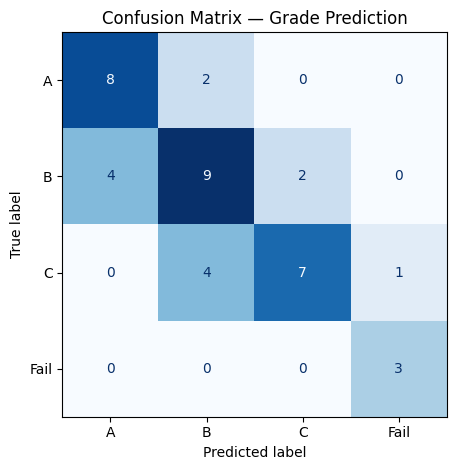

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['A', 'B', 'C', 'Fail'])

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['A', 'B', 'C', 'Fail'])
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Grade Prediction')
plt.tight_layout()
plt.show()

In [ ]:
# Accuracy, Precision, Recall, F1 — all in one
print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['A', 'B', 'C', 'Fail']))

print('=== Individual Metrics ===')
print(f'Accuracy  : {accuracy_score(y_test, y_pred):.2%}  — overall % correct')
print(f'Precision : {precision_score(y_test, y_pred, average="macro"):.2%}  — when it says a class, how often is it right?')
print(f'Recall    : {recall_score(y_test, y_pred, average="macro"):.2%}  — of the real class, how many did it catch?')
print(f'F1 Score  : {f1_score(y_test, y_pred, average="macro"):.2%}  — balance between precision & recall')

=== Classification Report ===
              precision    recall  f1-score   support

           A       0.67      0.80      0.73        10
           B       0.60      0.60      0.60        15
           C       0.78      0.58      0.67        12
        Fail       0.75      1.00      0.86         3

    accuracy                           0.68        40
   macro avg       0.70      0.75      0.71        40
weighted avg       0.68      0.68      0.67        40

=== Individual Metrics ===
Accuracy  : 67.50%  — overall % correct
Precision : 69.86%  — when it says a class, how often is it right?
Recall    : 74.58%  — of the real class, how many did it catch?
F1 Score  : 71.28%  — balance between precision & recall


---
## Part 3 — Decision Trees

A decision tree asks **yes/no questions** about the features to reach a prediction.

Think of it like a flowchart:
> *Did the student study more than 5 hours?*  
> → Yes → *Is their attendance above 70%?* → Yes → **B**  
> → No → **Fail**

### Simple example first: Weather → Play Outside?

In [ ]:
# A tiny, easy-to-understand dataset
# Can we predict if someone will play outside based on weather?

tennis = pd.read_csv('tennis.csv')

tennis

,outlook,temp,humidity,windy,play
0,sunny,hot,high,False,no
1,sunny,hot,high,True,no
2,overcast,hot,high,False,yes
3,rainy,mild,high,False,yes
4,rainy,cool,normal,False,yes
5,rainy,cool,normal,True,no
6,overcast,cool,normal,True,yes
7,sunny,mild,high,False,no
8,sunny,cool,normal,False,yes
9,rainy,mild,normal,False,yes


In [ ]:
# Decision trees in sklearn need numbers, not text
# So we encode each column: sunny=0, overcast=1, rainy=2 etc.
from sklearn.preprocessing import LabelEncoder

tennis_enc = tennis.copy()
le = LabelEncoder()
for col in tennis_enc.columns:
    tennis_enc[col] = le.fit_transform(tennis_enc[col])

print(tennis_enc)

    outlook  temp  humidity  windy  play
0         2     1         0      0     0
1         2     1         0      1     0
2         0     1         0      0     1
3         1     2         0      0     1
4         1     0         1      0     1
5         1     0         1      1     0
6         0     0         1      1     1
7         2     2         0      0     0
8         2     0         1      0     1
9         1     2         1      0     1
10        2     2         1      1     1
11        0     2         0      1     1
12        0     1         1      0     1
13        1     2         0      1     0


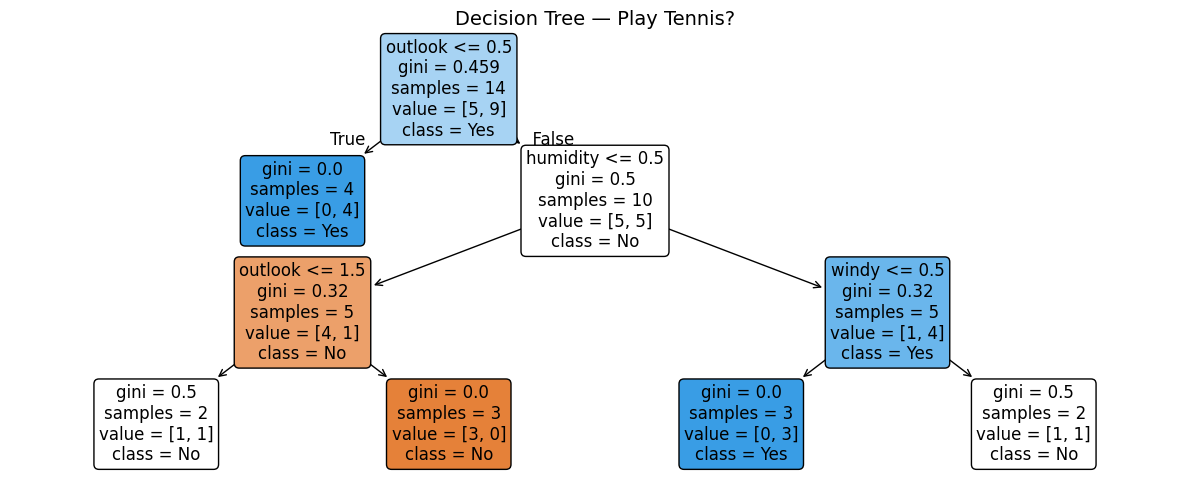

In [ ]:
X_t = tennis_enc.drop(columns=['play'])
y_t = tennis_enc['play']

tree_tennis = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_tennis.fit(X_t, y_t)

plt.figure(figsize=(12, 5))
plot_tree(
    tree_tennis,
    feature_names=list(X_t.columns),
    class_names=['No', 'Yes'],
    filled=True, rounded=True, fontsize=12
)
plt.title('Decision Tree — Play Tennis?', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Today: overcast, mild, normal humidity, not windy
# We need to encode it the same way the tree was trained
# outlook: overcast=0, rainy=1, sunny=2
# temp: cool=0, hot=1, mild=2
# humidity: high=0, normal=1
# windy: false=0, true=1

new_day = pd.DataFrame({
    'outlook':  [0],   # overcast
    'temp':     [2],   # mild
    'humidity': [1],   # normal
    'windy':    [0],   # false
})

result = tree_tennis.predict(new_day)[0]
print(f'Overcast, mild, normal, not windy → {"Play ✅" if result == 1 else "Don\'t play ❌"}')

Overcast, mild, normal, not windy → Play ✅
